In [2]:
# import sys
# print(sys.executable)

C:\conda_envs\ebm311\python.exe


In [3]:
# import sys
# !{sys.executable} -m pip install --force-reinstall numpy==1.26.4

   ---------------------------------------- 0.0/15.8 MB ? eta -:--:--
   ------------------ --------------------- 7.3/15.8 MB 41.2 MB/s eta 0:00:01
   ---------------------------------------  15.7/15.8 MB 41.2 MB/s eta 0:00:01
   ---------------------------------------- 15.8/15.8 MB 38.3 MB/s  0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.4.4
    Uninstalling numpy-2.4.4:
      Successfully uninstalled numpy-2.4.4


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
salib 1.5.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.


In [1]:
# import sys
# import numpy as np

# print(sys.executable)
# print(np.__version__)


C:\conda_envs\ebm311\python.exe
1.26.4


In [2]:
# 데이터 읽기용 코드셀입니다.

import pandas as pd
print('='*20, 'game.xlsx 데이터 정보입니다.', '='*20)
tmp_df = pd.read_excel('./game.xlsx', sheet_name='Sheet1')
display(tmp_df.shape)
display(tmp_df.columns)
display(tmp_df.head())

==================== game.xlsx 데이터 정보입니다. ====================


(2899, 9)

Index(['user_id', 'date', 'playtime', 'playcount', 'level', 'mainjob',
       'paycount', 'payamount', 'mainjoblevel'],
      dtype='str')

,user_id,date,playtime,playcount,level,mainjob,paycount,payamount,mainjoblevel
0,1001,2024-01-10,61,1.0,15,dealer,1,60300,60
1,1001,2024-01-11,14,1.0,15,dealer,1,100,60
2,1001,2024-01-12,16,1.0,15,tanker,1,151,60
3,1001,2024-01-13,1300,3.0,15,tanker,1,1000,60
4,1001,2024-01-14,41,3.0,15,tanker,1,16000,60


In [3]:
# Step2: 데이터 전처리
features = tmp_df[['playtime', 'playcount', 'level', 'paycount', 'payamount', 'mainjoblevel']]
target = tmp_df['mainjob']

print('='*20, 'features 정보입니다.', '='*20)
display(features.shape)
display(features.head())

print('='*20, 'target 정보입니다.', '='*20)
display(target.shape)
display(target.head())

==================== features 정보입니다. ====================


(2899, 6)

,playtime,playcount,level,paycount,payamount,mainjoblevel
0,61,1.0,15,1,60300,60
1,14,1.0,15,1,100,60
2,16,1.0,15,1,151,60
3,1300,3.0,15,1,1000,60
4,41,3.0,15,1,16000,60


==================== target 정보입니다. ====================


(2899,)

0    dealer
1    dealer
2    tanker
3    tanker
4    tanker
Name: mainjob, dtype: str

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

print('='*20, '분할 이후 train 데이터 크기입니다.', '='*20)
print(X_train.shape)
print(y_train.shape)

print('='*20, '분할 이후 test 데이터 크기입니다.', '='*20)
print(X_test.shape)
print(y_test.shape)

print('='*20, 'train 데이터와 test 데이터 비율 계산 결과입니다.', '='*20)
print(len(X_train) / len(features))
print(len(X_test) / len(features))

==================== 분할 이후 train 데이터 크기입니다. ====================
(2319, 6)
(2319,)
==================== 분할 이후 test 데이터 크기입니다. ====================
(580, 6)
(580,)
==================== train 데이터와 test 데이터 비율 계산 결과입니다. ====================
0.7999310106933425
0.20006898930665748


In [6]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_before = y_train.copy()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

==================== LabelEncoding 이전의 분포입니다. ====================


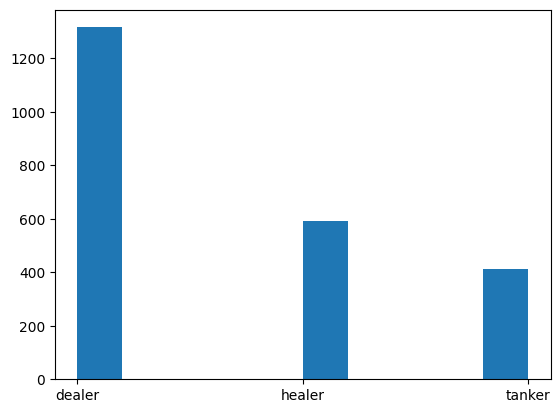

==================== LabelEncoding 이후의 분포입니다. ====================


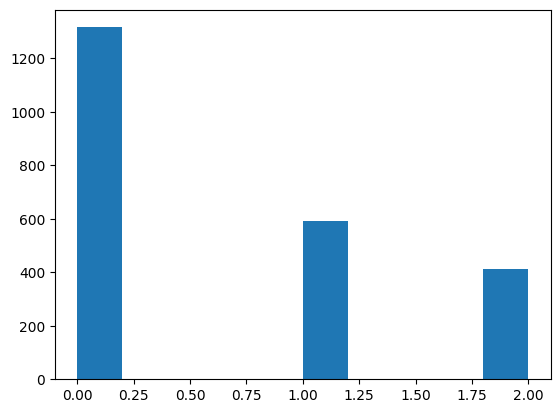

In [7]:
import matplotlib.pyplot as plt

print('='*20, 'LabelEncoding 이전의 분포입니다.', '='*20)
plt.hist(y_before)
plt.show()

print('='*20, 'LabelEncoding 이후의 분포입니다.', '='*20)
plt.hist(y_train)
plt.show()

In [7]:
from interpret.glassbox import ExplainableBoostingClassifier

ebm = ExplainableBoostingClassifier(random_state=42)
ebm.fit(X_train, y_train)

C:\conda_envs\ebm311\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:871: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(
C:\conda_envs\ebm311\Lib\site-packages\interpret\glassbox\_ebm\_ebm.py:1249: UserWarning: For multiclass we cannot currently visualize pairs and they will be stripped from the global explanations. Set interactions=0 to generate a fully interpretable glassbox model.
  warn(


,feature_names,None
,feature_types,None
,max_bins,1024
,max_interaction_bins,64
,interactions,'3x'
,exclude,None
,validation_size,0.15
,outer_bags,14
,inner_bags,0
,learning_rate,0.015
,greedy_ratio,10.0


In [8]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = ebm.predict(X_test)

print('='*20, 'accuracy 결과입니다.', '='*20)
print(accuracy_score(y_test, y_pred))

print('='*20, 'classification_report 결과입니다.', '='*20)
print(classification_report(y_test, y_pred, target_names=le.classes_))

==================== accuracy 결과입니다. ====================
0.9517241379310345
==================== classification_report 결과입니다. ====================
              precision    recall  f1-score   support

      dealer       0.95      0.97      0.96       320
      healer       0.97      0.96      0.96       137
      tanker       0.94      0.90      0.92       123

    accuracy                           0.95       580
   macro avg       0.95      0.94      0.95       580
weighted avg       0.95      0.95      0.95       580

